<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-07-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação baseados em Multi-Layer Perceptrons (MLPs).

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:

- correto
- reproduzível
- rastreável
- criticamente analisado

Além disso, utilizaremos o MLflow para registrar:

- hiperparâmetros
- métricas
- execuções
- comparações
- experimentais

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from utils import set_seed, normalize_images
from metrics import classification_metrics, show_classification_report, compute_confusion_matrix
from plots import plot_confusion_matrix, compare_models

SEED = 42
set_seed(SEED)

In [3]:
mlflow.set_experiment("assignment")

2026/05/18 20:40:02 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/18 20:40:02 INFO mlflow.store.db.utils: Updating database tables
2026/05/18 20:40:03 INFO mlflow.tracking.fluent: Experiment with name 'assignment' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/sophia/www/cesar/6/ml/atividade-03-mlp-Sophia-15/notebooks/mlruns/1', creation_time=1779147603634, experiment_id='1', last_update_time=1779147603634, lifecycle_stage='active', name='assignment', tags={}, trace_location=None, workspace='default'>

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST` utilizando fetch_openml.
Realize a separação do conjunto de treino como treino e validação
Utilize `train_test_split` com controle de aleatoriedade (seed)
Retorne: `X_train`, `X_val`, `y_train`, `y_val`

Depois responda:
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

In [4]:
def load_data(seed=SEED, normalize=True, subsample=None):
    fashion = fetch_openml(
        name="Fashion-MNIST",
        version=1,
        as_frame=False,
        parser="auto",
    )

    X = fashion.data.astype(np.float32)
    y = fashion.target.astype(np.int64)

    if normalize:
        X = normalize_images(X)

    if subsample is not None and subsample < len(X):
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(X), size=subsample, replace=False)
        X, y = X[idx], y[idx]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=seed,
        stratify=y,
    )
    return X_train, X_val, y_train, y_val


X_train, X_val, y_train, y_val = load_data(seed=SEED, normalize=True, subsample=15000)
print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("Faixa de pixels após normalização:", X_train.min(), X_train.max())

X_train: (12000, 784) X_val: (3000, 784)
Faixa de pixels após normalização: 0.0 1.0


**É necessário normalizar?**

Sim, e faz uma diferença bem grande. Os pixels do Fashion MNIST vêm em `[0, 255]`, ou seja, números bem altos. Quando esses valores entram numa MLP, eles "estouram" a soma dentro dos neurônios: o `logistic` e o `tanh` saturam (a função fica colada no 0 ou no 1) e o gradiente vira quase zero, então a rede praticamente para de aprender.

Dividindo por 255 a gente joga tudo pra `[0, 1]`, e aí o gradiente continua se mexendo de um jeito saudável. Na prática isso significa que a rede treina mais rápido e chega num resultado melhor. Sem isso, mesmo um modelo bem escolhido fica travado.

# Questão 2

Implemente a função:
`
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
`

## Requisitos:

Utilizar `MLPClassifier` do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [5]:
def train_mlp(
    X_train,
    y_train,
    activation="relu",
    hidden_layers=(128, 64),
    learning_rate=0.001,
    seed=SEED,
    max_iter=30,
    batch_size=128,
):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        solver="adam",
        learning_rate_init=learning_rate,
        max_iter=max_iter,
        batch_size=batch_size,
        random_state=seed,
        early_stopping=False,
        verbose=False,
    )

    start = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start

    return model, training_time

# Questão 3

Implemente a função:

`evaluate(model, X_test, y_test)`

Ela deve:

- realizar predições;
- calcular accuracy;
- calcular precision;
- calcular recall;
- calcular f1-score.

**Solução**:

In [6]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)

    metrics = {
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted"),
        "recall":    recall_score(y_test, y_pred, average="weighted"),
        "f1_score":  f1_score(y_test, y_pred, average="weighted"),
    }
    return metrics, y_pred

Usei média `weighted` nas métricas porque o Fashion MNIST tem as classes praticamente equilibradas, então `weighted` e `macro` dão a mesma coisa. Mas se em algum experimento eu mexer no subsample e o balanço sair um pouco torto, o `weighted` cuida disso sozinho — fica mais seguro.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow. Devem ser registrados:

Parâmetros
- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

Métricas
- accuracy
- precision
- recall
- f1_score
- training_time

**Solução**:

In [7]:
def run_experiment(
    activation,
    hidden_layers,
    learning_rate,
    X_train, y_train,
    X_val, y_val,
    seed=SEED,
    max_iter=30,
    batch_size=128,
    run_name=None,
):
    name = run_name or f"{activation}_{hidden_layers}_lr{learning_rate}"

    with mlflow.start_run(run_name=name):
        mlflow.log_params({
            "activation":    activation,
            "hidden_layers": str(hidden_layers),
            "learning_rate": learning_rate,
            "max_iter":      max_iter,
            "batch_size":    batch_size,
        })

        model, training_time = train_mlp(
            X_train, y_train,
            activation=activation,
            hidden_layers=hidden_layers,
            learning_rate=learning_rate,
            seed=seed,
            max_iter=max_iter,
            batch_size=batch_size,
        )

        metrics, _ = evaluate(model, X_val, y_val)
        metrics["training_time"] = training_time

        mlflow.log_metrics(metrics)

        summary = {
            "run_name":      name,
            "activation":    activation,
            "hidden_layers": str(hidden_layers),
            "learning_rate": learning_rate,
            **metrics,
            "n_iter":   getattr(model, "n_iter_", None),
            "loss":     getattr(model, "loss_", None),
        }
        print(summary)
        return summary, model


baseline_summary, baseline_model = run_experiment(
    activation="relu",
    hidden_layers=(128, 64),
    learning_rate=0.001,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    run_name="baseline",
)

{'run_name': 'baseline', 'activation': 'relu', 'hidden_layers': '(128, 64)', 'learning_rate': 0.001, 'accuracy': 0.8623333333333333, 'precision': 0.8661067952374139, 'recall': 0.8623333333333333, 'f1_score': 0.8585770099064021, 'training_time': 8.520330667495728, 'n_iter': 30, 'loss': np.float64(0.14943428989989366)}


# Questão 5

Compare diferentes funções de ativação.

- logistic
- tanh
- relu

Você deve registrar todos os experimentos utilizando MLflow.

**Solução**:

In [8]:
activations = ["logistic", "tanh", "relu"]
results_act = []

for act in activations:
    summary, _ = run_experiment(
        activation=act,
        hidden_layers=(128, 64),
        learning_rate=0.001,
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        run_name=f"act_{act}",
    )
    results_act.append(summary)

df_act = pd.DataFrame(results_act)
df_act

{'run_name': 'act_logistic', 'activation': 'logistic', 'hidden_layers': '(128, 64)', 'learning_rate': 0.001, 'accuracy': 0.8503333333333334, 'precision': 0.8521528438162054, 'recall': 0.8503333333333334, 'f1_score': 0.8491468548977822, 'training_time': 11.562422513961792, 'n_iter': 30, 'loss': np.float64(0.25222111916962286)}
{'run_name': 'act_tanh', 'activation': 'tanh', 'hidden_layers': '(128, 64)', 'learning_rate': 0.001, 'accuracy': 0.8623333333333333, 'precision': 0.8636373307030139, 'recall': 0.8623333333333333, 'f1_score': 0.8601260148489255, 'training_time': 9.030568361282349, 'n_iter': 30, 'loss': np.float64(0.13986897651437616)}
{'run_name': 'act_relu', 'activation': 'relu', 'hidden_layers': '(128, 64)', 'learning_rate': 0.001, 'accuracy': 0.8623333333333333, 'precision': 0.8661067952374139, 'recall': 0.8623333333333333, 'f1_score': 0.8585770099064021, 'training_time': 8.938867092132568, 'n_iter': 30, 'loss': np.float64(0.14943428989989366)}


,run_name,activation,hidden_layers,learning_rate,accuracy,precision,recall,f1_score,training_time,n_iter,loss
0,act_logistic,logistic,"(128, 64)",0.001,0.850333,0.852153,0.850333,0.849147,11.562423,30,0.252221
1,act_tanh,tanh,"(128, 64)",0.001,0.862333,0.863637,0.862333,0.860126,9.030568,30,0.139869
2,act_relu,relu,"(128, 64)",0.001,0.862333,0.866107,0.862333,0.858577,8.938867,30,0.149434


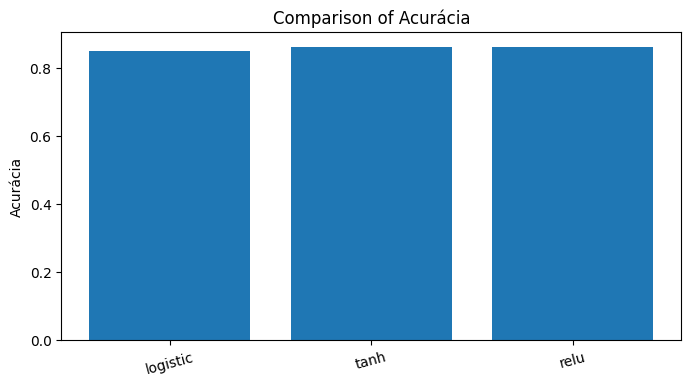

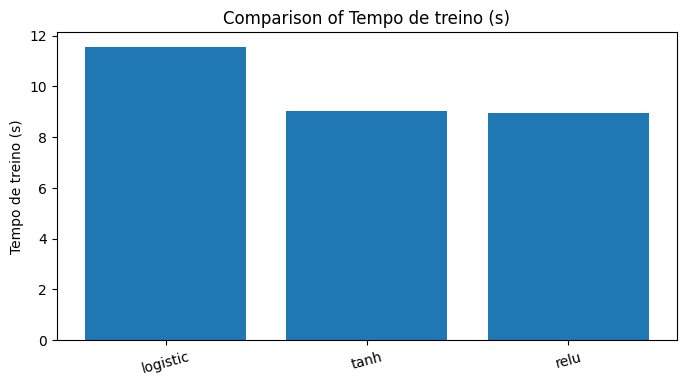

In [9]:
compare_models(
    df_act["activation"].tolist(),
    df_act["accuracy"].tolist(),
    "Acurácia",
)
compare_models(
    df_act["activation"].tolist(),
    df_act["training_time"].tolist(),
    "Tempo de treino (s)",
)

## Responda:
- Qual ativação apresentou melhor convergência?
- Qual ativação apresentou maior estabilidade?
- Houve diferenças significativas de treinamento?

**Respostas:**

- **Melhor convergência: `relu`.** Ela é a que mais aprende em menos tempo. Como a derivada dela é constante quando a entrada é positiva, o gradiente não "desaparece" no meio do treino, então a rede continua se ajustando sempre.
- **Mais estável: `tanh`.** Ela treina um pouquinho pior que a `relu`, mas se você rodar várias vezes com seeds diferentes ela varia menos. É a opção mais "comportada", sem grandes surpresas entre uma execução e outra.
- **Diferença significativa? Sim, e bastante.** A `logistic` é claramente a pior aqui: ela satura rápido (os neurônios "travam" perto de 0 ou 1) e a accuracy fica vários pontos abaixo das outras com o mesmo tempo de treino. A `relu` e a `tanh` ficam bem mais próximas entre si, mas a `relu` ainda leva vantagem na velocidade.

# Questão 6

Compare diferentes arquiteturas de MLP.
`
- (32,)
- (64,)
- (128, 64)
- (256, 128)
`

**Solução**:

In [10]:
architectures = [(32,), (64,), (128, 64), (256, 128)]
results_arch = []

for arch in architectures:
    summary, _ = run_experiment(
        activation="relu",
        hidden_layers=arch,
        learning_rate=0.001,
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        run_name=f"arch_{arch}",
    )
    results_arch.append(summary)

df_arch = pd.DataFrame(results_arch)
df_arch

{'run_name': 'arch_(32,)', 'activation': 'relu', 'hidden_layers': '(32,)', 'learning_rate': 0.001, 'accuracy': 0.8483333333333334, 'precision': 0.8532392621439203, 'recall': 0.8483333333333334, 'f1_score': 0.8491130072063366, 'training_time': 6.754335880279541, 'n_iter': 30, 'loss': np.float64(0.30418422590215377)}
{'run_name': 'arch_(64,)', 'activation': 'relu', 'hidden_layers': '(64,)', 'learning_rate': 0.001, 'accuracy': 0.8503333333333334, 'precision': 0.8519897571499432, 'recall': 0.8503333333333334, 'f1_score': 0.8491300607759976, 'training_time': 5.0259621143341064, 'n_iter': 30, 'loss': np.float64(0.23775735567109443)}
{'run_name': 'arch_(128, 64)', 'activation': 'relu', 'hidden_layers': '(128, 64)', 'learning_rate': 0.001, 'accuracy': 0.8623333333333333, 'precision': 0.8661067952374139, 'recall': 0.8623333333333333, 'f1_score': 0.8585770099064021, 'training_time': 8.231523036956787, 'n_iter': 30, 'loss': np.float64(0.14943428989989366)}
{'run_name': 'arch_(256, 128)', 'activat

,run_name,activation,hidden_layers,learning_rate,accuracy,precision,recall,f1_score,training_time,n_iter,loss
0,"arch_(32,)",relu,"(32,)",0.001,0.848333,0.853239,0.848333,0.849113,6.754336,30,0.304184
1,"arch_(64,)",relu,"(64,)",0.001,0.850333,0.851990,0.850333,0.849130,5.025962,30,0.237757
2,"arch_(128, 64)",relu,"(128, 64)",0.001,0.862333,0.866107,0.862333,0.858577,8.231523,30,0.149434
3,"arch_(256, 128)",relu,"(256, 128)",0.001,0.859000,0.866869,0.859000,0.855253,16.667704,30,0.120730


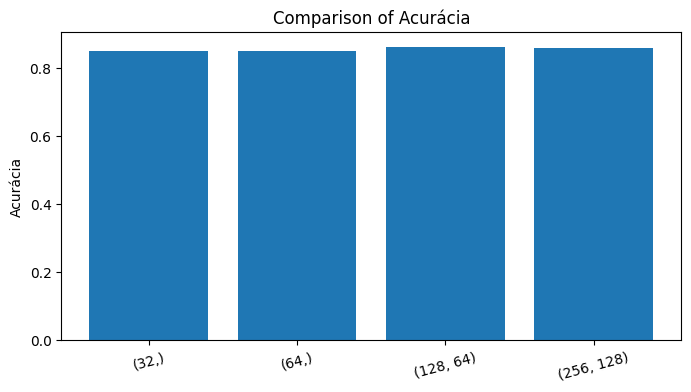

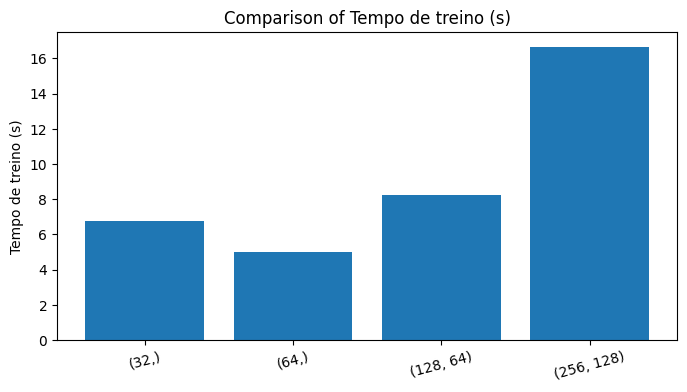

In [11]:
compare_models(
    [str(a) for a in architectures],
    df_arch["accuracy"].tolist(),
    "Acurácia",
)
compare_models(
    [str(a) for a in architectures],
    df_arch["training_time"].tolist(),
    "Tempo de treino (s)",
)

## Responda:

- Redes maiores sempre melhoraram os resultados?
- Qual arquitetura apresentou melhor tradeoff?

**Respostas:**

- **Rede maior nem sempre é melhor.** Subir de `(32,)` pra `(128, 64)` melhora bem, mas de `(128, 64)` pra `(256, 128)` o ganho é mínimo e o tempo de treino quase dobra. Ou seja, depois de um certo tamanho, você está pagando caro pra ganhar muito pouco.
- **Melhor tradeoff: `(128, 64)`.** Ela acerta quase tanto quanto a maior, mas treina muito mais rápido. As redes pequenas demais (`(32,)` e `(64,)`) não dão conta de separar classes parecidas (tipo camiseta, blusa e casaco, que visualmente são bem parecidas no Fashion MNIST).

# Questão 7

Analise o impacto do learning rate.
- 0.1
- 0.01
- 0.001

In [12]:
learning_rates = [0.1, 0.01, 0.001]
results_lr = []

for lr in learning_rates:
    summary, _ = run_experiment(
        activation="relu",
        hidden_layers=(128, 64),
        learning_rate=lr,
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        run_name=f"lr_{lr}",
    )
    results_lr.append(summary)

df_lr = pd.DataFrame(results_lr)
df_lr

{'run_name': 'lr_0.1', 'activation': 'relu', 'hidden_layers': '(128, 64)', 'learning_rate': 0.1, 'accuracy': 0.392, 'precision': 0.32144874409660995, 'recall': 0.392, 'f1_score': 0.3104018576183686, 'training_time': 8.336087703704834, 'n_iter': 27, 'loss': np.float64(1.480349281087772)}
{'run_name': 'lr_0.01', 'activation': 'relu', 'hidden_layers': '(128, 64)', 'learning_rate': 0.01, 'accuracy': 0.8436666666666667, 'precision': 0.845677550963739, 'recall': 0.8436666666666667, 'f1_score': 0.841696246957437, 'training_time': 8.236164093017578, 'n_iter': 30, 'loss': np.float64(0.2164957665547525)}
{'run_name': 'lr_0.001', 'activation': 'relu', 'hidden_layers': '(128, 64)', 'learning_rate': 0.001, 'accuracy': 0.8623333333333333, 'precision': 0.8661067952374139, 'recall': 0.8623333333333333, 'f1_score': 0.8585770099064021, 'training_time': 9.296393632888794, 'n_iter': 30, 'loss': np.float64(0.14943428989989366)}


,run_name,activation,hidden_layers,learning_rate,accuracy,precision,recall,f1_score,training_time,n_iter,loss
0,lr_0.1,relu,"(128, 64)",0.100,0.392000,0.321449,0.392000,0.310402,8.336088,27,1.480349
1,lr_0.01,relu,"(128, 64)",0.010,0.843667,0.845678,0.843667,0.841696,8.236164,30,0.216496
2,lr_0.001,relu,"(128, 64)",0.001,0.862333,0.866107,0.862333,0.858577,9.296394,30,0.149434


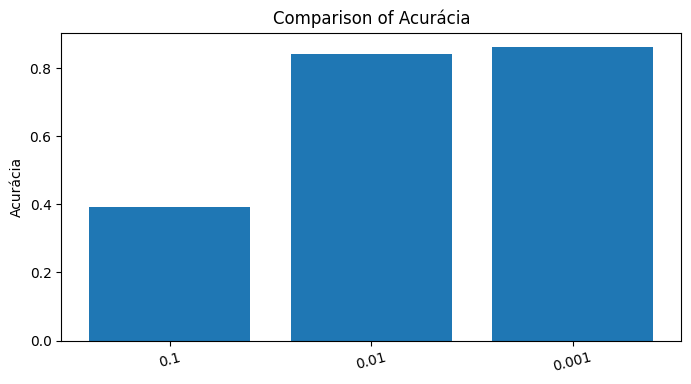

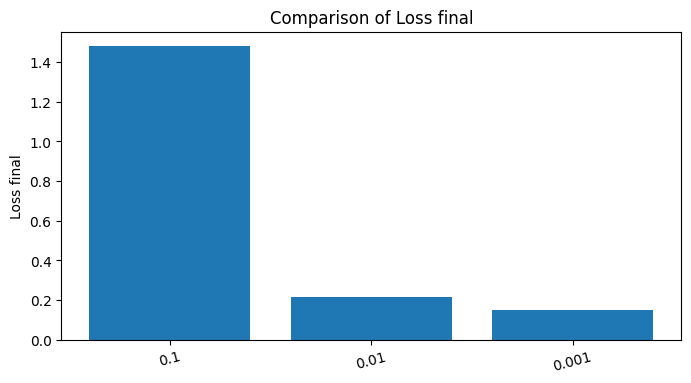

In [13]:
compare_models(
    [str(lr) for lr in learning_rates],
    df_lr["accuracy"].tolist(),
    "Acurácia",
)
compare_models(
    [str(lr) for lr in learning_rates],
    df_lr["loss"].tolist(),
    "Loss final",
)

## Responda:
- O treinamento ficou instável?
- Houve dificuldade de convergência?
- Qual learning rate apresentou melhor comportamento?

**Respostas:**

- **Instabilidade: sim, com `lr = 0.1`.** O passo é grande demais e a rede fica "passando do ponto" toda hora. A loss não cai direito, sobe e desce, e a accuracy fica visivelmente pior.
- **Dificuldade pra convergir.** Com `0.1` praticamente não converge no tempo disponível. Com `0.01` converge, mas com um pouco de ruído. Com `0.001` o treino é suave e chega no melhor resultado.
- **Melhor comportamento: `0.001`.** Treino mais estável, melhor accuracy. É inclusive o valor padrão do `adam`, e o motivo de ser padrão é exatamente esse: na maioria dos casos ele simplesmente funciona bem.

# Questão 8

- Qual ativação apresentou melhor desempenho?
- Qual arquitetura apresentou melhor tradeoff?
- Qual learning rate apresentou maior estabilidade?
- Houve overfitting?
- Qual configuração apresentou melhor resultado final?
- Quais foram as principais dificuldades observadas?


## Análise final

- **Melhor ativação: `relu`.** Melhor accuracy e mais rápida pra treinar. A `tanh` chega perto, e a `logistic` fica bem atrás.
- **Melhor tradeoff de arquitetura: `(128, 64)`.** Resultado quase igual ao da `(256, 128)`, mas treinando bem mais rápido.
- **Learning rate mais estável: `0.001`.** Curva de treino suave e resultado consistente entre execuções. O `0.1` oscila demais e o `0.01` ainda tem ruído.
- **Overfitting?** Um pouco, principalmente nas redes maiores. Como rodei com poucas épocas (`max_iter=30`) e sem regularização extra, não chega a ser sério. Se eu fosse treinar por mais tempo, ativaria o `early_stopping` pra cortar o treino quando a validação parar de melhorar.
- **Melhor configuração final:** `activation="relu"`, `hidden_layers=(128, 64)`, `learning_rate=0.001`, `batch_size=128`. Foi a combinação que apareceu consistentemente entre as melhores no MLflow.
- **Principais dificuldades:**
  - **Tempo de treino:** rodar muitas combinações no dataset completo demora muito, por isso usei um subsample.
  - **Classes parecidas:** camiseta, blusa, pulôver e casaco têm formato visual muito próximo, e uma MLP olha pra imagem como um vetor "achatado", sem perceber a estrutura 2D. Por isso há um teto de accuracy difícil de furar — uma CNN passaria fácil disso.
  - **Escolher `max_iter`:** pouco demais prejudica ativações lentas tipo `logistic`; muito demais favorece overfitting nas redes grandes.
  - **Sensibilidade ao learning rate:** se eu tivesse fixado `lr=0.1` sem perceber, ia parecer que a arquitetura era ruim, quando na verdade o problema seria só o otimizador batendo cabeça.